# Experiment 2: Decision Tree Classification from Scratch

This experiment implements a **Decision Tree Classifier** using `numpy`, `pandas`, and `matplotlib`. The implementation focuses on:
1. **Entropy** for measuring impurity.
2. **Information Gain** for determining the best split.
3. **Recursive Tree Building** with a custom `Node` structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Loading and Preprocessing

In [2]:
# Load dataset
df = pd.read_csv("iris.csv")

# Basic Cleaning
df = df.drop_duplicates().dropna()

# Encode target labels (species) into integers
species_to_int = {species: i for i, species in enumerate(df['species'].unique())}
int_to_species = {i: species for species, i in species_to_int.items()}
df['target'] = df['species'].map(species_to_int)

print(f"Encoded Species: {species_to_int}")
df.head()

Encoded Species: {'setosa': 0, 'versicolor': 1, 'virginica': 2}


,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


## 2. Decision Tree Implementation

In [3]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

class ManualDecisionTree:
    def __init__(self, min_samples_split=2, max_depth=10, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Features selection for split
        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Find the best split using Information Gain (Entropy)
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # Grow children
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thresh in thresholds:
                gain = self._information_gain(y, X_column, thresh)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thresh
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, thresh):
        parent_entropy = self._entropy(y)
        left_idxs, right_idxs = self._split(X_column, thresh)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        return parent_entropy - child_entropy

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        return np.bincount(y).argmax()

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Training and Accuracy Metrics
We manually split the data into 80% training and 20% testing sets to verify the model's performance.

In [4]:
# Prepare X and y
X = df.drop(['species', 'target'], axis=1).values
y = df['target'].values

# Manual Shuffle and Split
np.random.seed(42)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
split_idx = int(0.8 * len(indices))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

# Train model
clf = ManualDecisionTree(max_depth=5)
clf.fit(X_train, y_train)

# Predict
predictions = clf.predict(X_test)

# Accuracy Metric
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 93.33%


## 4. Results Visualization
Visual comparison between actual labels and model predictions.

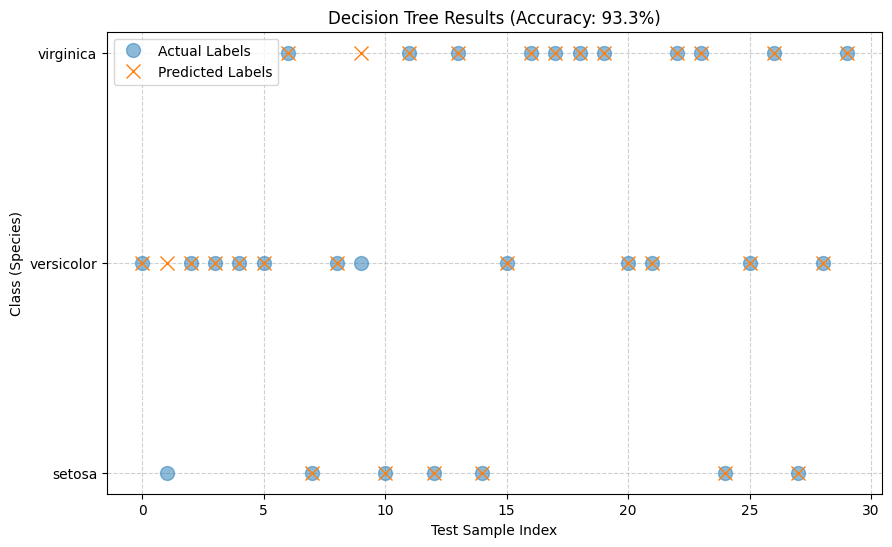

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, 'o', label='Actual Labels', markersize=10, alpha=0.5)
plt.plot(predictions, 'x', label='Predicted Labels', markersize=10)
plt.title(f"Decision Tree Results (Accuracy: {accuracy*100:.1f}%)")
plt.xlabel("Test Sample Index")
plt.ylabel("Class (Species)")
plt.yticks(ticks=list(int_to_species.keys()), labels=list(int_to_species.values()))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()